In [4]:
#### ------------------------------------------------------------------------------------------
#### author: Ranjan Barman, date: Jun 2, 2025
#### Compute 12NPIFs from immune-only nuclei based on HoverNet prediction, using MPP = 0.248
#### Removes outliers for Major Axis and Minor Axis using IQR
#### --------------------------------------------------------------------------------------------

import os
import pandas as pd
import numpy as np

# Set working directory
_wpath_ = "/data/Lab_ruppin/Ranjan/HnE/"
os.makedirs(_wpath_, exist_ok=True)
os.chdir(_wpath_)
print("Working directory:", _wpath_)

# Define dataset name and output file path
dataset_name = "CPTAC_BRCA"
input_folder = f"{dataset_name}/HoverNet/outputs/"
output_file_path = f"{dataset_name}/HoverNet/outputs/CPTAC_BRCA_HoverNet_ImmuneOnly_NPIFs.csv"

# Columns to compute
columns_to_compute = ["Area", "Major Axis", "Minor Axis", "Perimeter", "Eccentricity", "Circularity"]

# MPP (microns per pixel) for 40X
MPP = 0.248

# Outlier removal function
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

# Collect results
results = []

# Get all folders for tiles
cptac_folders = [f for f in os.listdir(input_folder) if os.path.isdir(os.path.join(input_folder, f)) and f.endswith("_tiles")]

for slide_name in cptac_folders:
    feature_file = os.path.join(input_folder, slide_name, "features3", f"{slide_name}.csv")
    
    if not os.path.exists(feature_file):
        print(f"File not found: {feature_file}, skipping...")
        continue

    # Read immune-only feature CSV
    df = pd.read_csv(feature_file)

    # Unit conversion
    df["Area"] = df["Area"] * (MPP ** 2)
    df["Major Axis"] = df["Major Axis"] * MPP
    df["Minor Axis"] = df["Minor Axis"] * MPP
    df["Perimeter"] = df["Perimeter"] * MPP

    # Remove outliers for axes
    df = remove_outliers(df, "Major Axis")
    df = remove_outliers(df, "Minor Axis")

    # Compute mean and std
    mean_vals = df[columns_to_compute].mean()
    std_vals = df[columns_to_compute].std()

    results.append([slide_name] + mean_vals.tolist() + std_vals.tolist())

# Create dataframe
result_df = pd.DataFrame(
    results,
    columns=["Slide_Name"] + [f"Mean {col}" for col in columns_to_compute] + 
             [f"Std {col}" for col in columns_to_compute]
)

# Replace NaN or Inf with mean or zero
result_df.replace([np.inf, -np.inf], np.nan, inplace=True)
result_df.fillna(result_df.mean(numeric_only=True), inplace=True)
result_df.fillna(0, inplace=True)


Working directory: /data/Lab_ruppin/Ranjan/HnE/
File not found: CPTAC_BRCA/HoverNet/outputs/05BR043-fa94c9c9-e483-473b-a8cc-af5a28_0_tiles/features3/05BR043-fa94c9c9-e483-473b-a8cc-af5a28_0_tiles.csv, skipping...
File not found: CPTAC_BRCA/HoverNet/outputs/01BR024-37f75ca4-0b11-4781-8f9d-7453dd_0_tiles/features3/01BR024-37f75ca4-0b11-4781-8f9d-7453dd_0_tiles.csv, skipping...
File not found: CPTAC_BRCA/HoverNet/outputs/01BR040-75caa191-2bf6-4cd7-9eff-03ad98_0_tiles/features3/01BR040-75caa191-2bf6-4cd7-9eff-03ad98_0_tiles.csv, skipping...


In [5]:
result_df

,Slide_Name,Mean Area,Mean Major Axis,Mean Minor Axis,Mean Perimeter,Mean Eccentricity,Mean Circularity,Std Area,Std Major Axis,Std Minor Axis,Std Perimeter,Std Eccentricity,Std Circularity
0,03BR011-3a210a6b-bdf1-4407-94c8-7bb085_275_tiles,9.585407,4.306655,2.984109,12.109914,0.683892,0.784195,4.435060,1.078972,0.736593,2.942613,0.137911,0.071189
1,13BR003-dc061ec0-a115-4905-be45-83ec1c_281_tiles,7.586358,3.806407,2.649712,10.688833,0.676245,0.791226,3.921026,1.068531,0.685913,2.895536,0.140738,0.069397
2,05BR026-c19af02c-8e00-4169-9d43-c60995_312_tiles,6.396440,3.495283,2.475496,9.869972,0.667961,0.794319,2.934198,0.830403,0.561047,2.293371,0.139000,0.067435
3,05BR040-4ca1e8bc-0c34-42bf-80c9-271517_374_tiles,6.508004,3.502258,2.501007,9.915680,0.657268,0.800243,3.102319,0.882860,0.593923,2.427695,0.146034,0.076001
4,01BR002-5a2a6cb6-59c1-4eda-b0f2-fbf2b6_304_tiles,6.807462,3.668724,2.524631,10.253407,0.684688,0.790623,2.788168,0.870209,0.502150,2.231237,0.137245,0.065558
...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,01BR023-7aa930f5-4933-4cea-9f24-a132f7_759_tiles,9.216271,4.175269,2.959571,11.855092,0.661619,0.792352,4.227703,1.074590,0.690969,2.894312,0.146384,0.076589
645,11BR048-951826c2-86b6-44e1-8ca4-142861_1671_tiles,6.914307,3.603415,2.570258,10.200112,0.657551,0.800081,3.448853,0.966111,0.613161,2.600052,0.143159,0.072504
646,11BR013-faadb553-9437-42cb-b469-498d67_1645_tiles,7.579721,3.773220,2.735346,10.853953,0.648433,0.783066,3.222597,0.872588,0.592941,2.448521,0.143800,0.075174
647,18BR019-3a987590-ed76-44f9-b7e5-e8ea5f_1590_tiles,6.321378,3.483920,2.472682,9.997776,0.664432,0.772859,2.820756,0.848356,0.560966,2.472477,0.141549,0.087054


In [6]:
# Extract the patient ID from the first 7 characters of Slide_Name
result_df['Patient_ID'] = result_df['Slide_Name'].str[:7]

# Compute the average feature values across all slides for each patient
patient_avg_df = result_df.groupby('Patient_ID').mean(numeric_only=True)

# Save results to CSV
os.makedirs(os.path.dirname(output_file_path), exist_ok=True)  # Ensure directory exists
patient_avg_df.to_csv(output_file_path)

print(f"Converted results saved to: {output_file_path}")

patient_avg_df

Converted results saved to: CPTAC_BRCA/HoverNet/outputs/CPTAC_BRCA_HoverNet_ImmuneOnly_NPIFs.csv


,Mean Area,Mean Major Axis,Mean Minor Axis,Mean Perimeter,Mean Eccentricity,Mean Circularity,Std Area,Std Major Axis,Std Minor Axis,Std Perimeter,Std Eccentricity,Std Circularity
Patient_ID,,,,,,,,,,,,
01BR001,7.625997,3.787263,2.722527,10.771633,0.653359,0.790338,3.555293,0.950318,0.630684,2.575763,0.145582,0.068284
01BR002,6.445517,3.562513,2.464228,9.945418,0.678562,0.794214,2.584343,0.829129,0.489916,2.104626,0.144999,0.068413
01BR003,6.937962,3.689351,2.536491,10.287554,0.687854,0.796863,2.934617,0.875156,0.527932,2.306128,0.135241,0.066716
01BR004,7.826112,3.719603,2.817132,10.760318,0.614977,0.816394,3.415610,0.841308,0.619842,2.372559,0.144370,0.059871
01BR005,6.812194,3.571996,2.582289,10.170890,0.650610,0.796482,3.094846,0.844645,0.563091,2.360535,0.142419,0.072344
...,...,...,...,...,...,...,...,...,...,...,...,...
22BR005,7.218849,3.688916,2.640166,10.482135,0.657364,0.794211,3.221034,0.892752,0.585841,2.409777,0.141812,0.066819
22BR006,4.782527,3.028750,2.167473,8.614594,0.655039,0.785052,2.088553,0.721420,0.445609,1.961325,0.143788,0.077641
22BR007,6.292264,3.483373,2.444456,9.902195,0.674106,0.769903,3.115829,0.891664,0.615885,2.519331,0.140765,0.076440


In [7]:
patient_avg_df.describe()

,Mean Area,Mean Major Axis,Mean Minor Axis,Mean Perimeter,Mean Eccentricity,Mean Circularity,Std Area,Std Major Axis,Std Minor Axis,Std Perimeter,Std Eccentricity,Std Circularity
count,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000
mean,6.967462,3.609145,2.586053,10.249062,0.655516,0.795907,3.198090,0.889270,0.586144,2.421727,0.142983,0.070626
std,1.015006,0.260421,0.177678,0.726012,0.015803,0.009351,0.611940,0.103088,0.080217,0.289487,0.003660,0.004595
min,4.598705,2.924835,2.167473,8.359355,0.595309,0.766110,1.689233,0.631124,0.358398,1.657714,0.130719,0.059871
25%,6.294893,3.448378,2.458654,9.812991,0.645938,0.790478,2.779543,0.822688,0.529757,2.240926,0.141429,0.067709
50%,6.954608,3.620512,2.588705,10.289204,0.657798,0.796075,3.156907,0.884105,0.585479,2.411693,0.142708,0.070620
75%,7.652001,3.770085,2.703959,10.742698,0.666674,0.802339,3.542366,0.952657,0.631399,2.590849,0.144222,0.073506
max,10.054247,4.322672,3.085345,12.184027,0.687854,0.822588,5.235155,1.150180,0.818164,3.181531,0.175973,0.089217


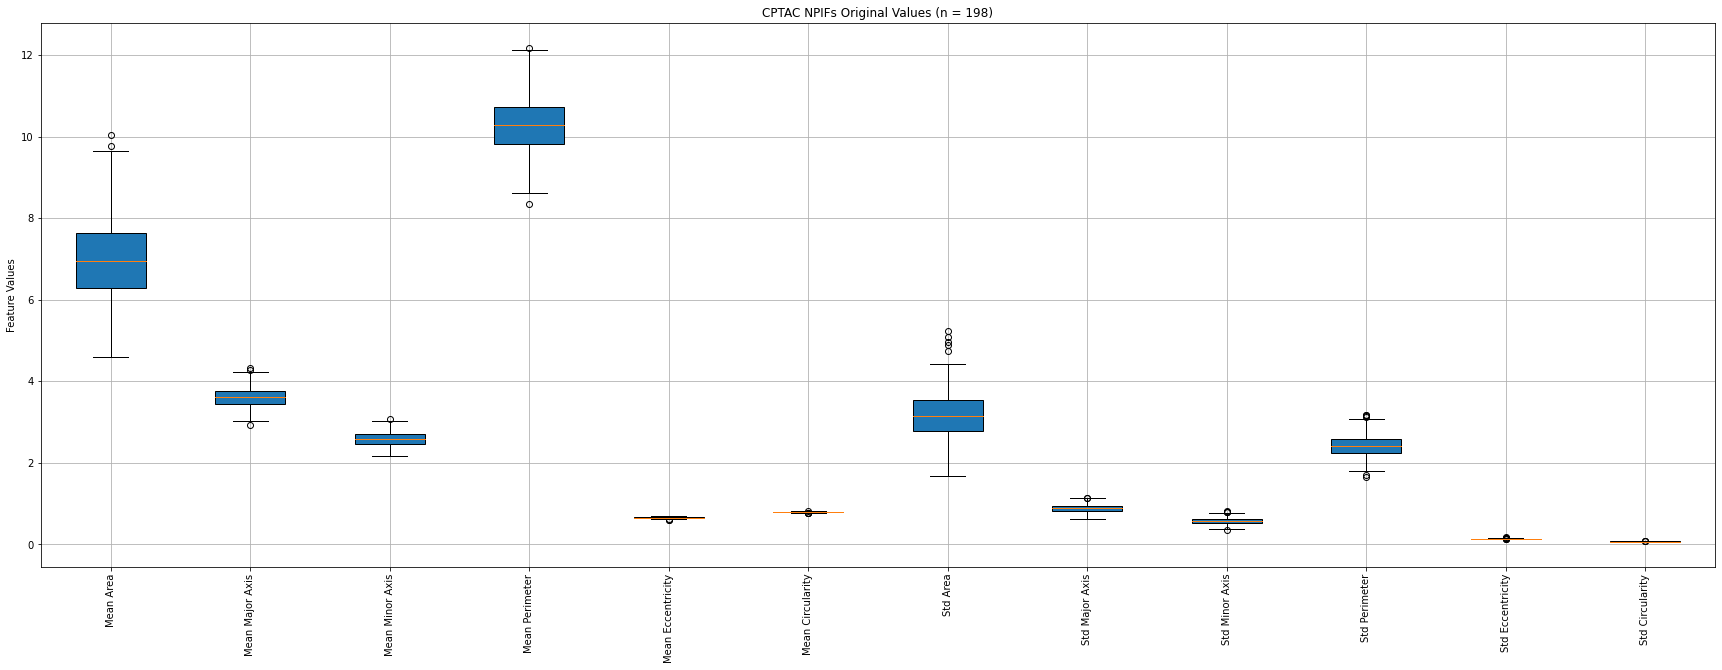

In [8]:
# Import required library
import matplotlib.pyplot as plt

# Select only NPIF features (excluding the first column 'Slide_Name')
cptac_features = patient_avg_df

# Number of samples in the dataset
n_cptac = cptac_features.shape[0]

# Plot boxplots for PathAI NPIFs
plt.figure(figsize=(30, 10))
plt.boxplot(cptac_features.values, labels=cptac_features.columns, vert=True, patch_artist=True)
plt.xticks(rotation=90)
plt.title(f"CPTAC NPIFs Original Values (n = {n_cptac})")
plt.ylabel("Feature Values")
plt.grid(True)
plt.show()